# Conditional Neural Movement Primitives — usage

A batched CNMP (Seker et al., RSS 2019) with padding masks, so that **every element of a
batch may use a different number of context and target points**.

* `cnmp.py` — the model (encoder → masked mean aggregation → decoder → Gaussian).
* `cnmp_data.py` — vectorised masked batch sampling + a toy dataset.
* `test_cnmp.py` — sanity checks (masking invariance, padding-independence of the loss, ...).

The demo task is a 2-D obstacle-avoidance skill in the spirit of Fig. 4 of the paper:
each demonstration goes from left to right, passing an invisible obstacle **either above or
below** it. The obstacle height is given to the model as a task parameter `γ`; which side the
trajectory passes is *not*, so the skill is bimodal given `γ`.

In [1]:
%matplotlib inline
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

from cnmp import CNMP
from cnmp_test_data import TrajectorySampler, build_query, generate_avoidance_trajectories

torch.manual_seed(0)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda:0


## 1. Data

`SM(t)` is 2-D here (task-space x and y). `γ` is the obstacle height.

SM: (200, 200, 2)   gamma: (200, 1)   train/val: 180/20


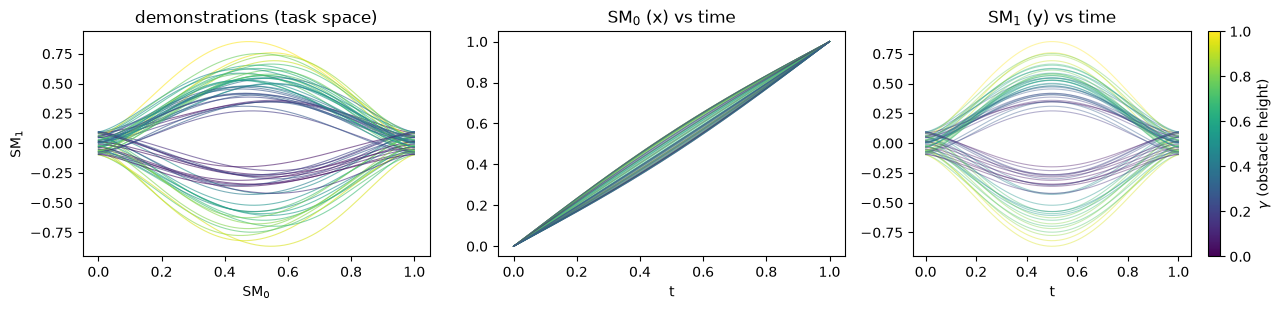

In [2]:
T_STEPS = 200
NUM_TRAJ = 200
NUM_VAL = 20

Y, G, MODE = generate_avoidance_trajectories(NUM_TRAJ, t_steps=T_STEPS, seed=0)
time_grid = torch.linspace(0, 1, T_STEPS).unsqueeze(-1)   # (T, 1), shared by all demos

perm = torch.randperm(NUM_TRAJ)
train_ids, val_ids = perm[NUM_VAL:], perm[:NUM_VAL]
print(f"SM: {tuple(Y.shape)}   gamma: {tuple(G.shape)}   train/val: {len(train_ids)}/{len(val_ids)}")

fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
for i in range(0, NUM_TRAJ, 3):
    c = plt.cm.viridis(G[i].item())
    axes[0].plot(Y[i, :, 0], Y[i, :, 1], color=c, lw=0.8, alpha=0.6)
    axes[1].plot(time_grid[:, 0], Y[i, :, 0], color=c, lw=0.8, alpha=0.4)
    axes[2].plot(time_grid[:, 0], Y[i, :, 1], color=c, lw=0.8, alpha=0.4)
axes[0].set(title="demonstrations (task space)", xlabel="SM$_0$", ylabel="SM$_1$")
axes[1].set(title="SM$_0$ (x) vs time", xlabel="t")
axes[2].set(title="SM$_1$ (y) vs time", xlabel="t")
fig.colorbar(plt.cm.ScalarMappable(cmap="viridis"), ax=axes[2], label=r"$\gamma$ (obstacle height)")
plt.tight_layout(); plt.show()

## 2. Masked batches

`TrajectorySampler` draws, per batch element, $n_i \sim U[1, n_{max}]$ observations and
$m_i \sim U[1, m_{max}]$ targets from a *single* demonstration, pads them to
`n_max` / `m_max`, and returns the boolean masks. Everything is vectorised over the batch.

In [3]:
N_MAX, M_MAX, BATCH = 32, 32, 32

train_sampler = TrajectorySampler(
    Y[train_ids], x=time_grid, gamma=G[train_ids],
    n_max=N_MAX, m_max=M_MAX, device=device, seed=0,
)
val_sampler = TrajectorySampler(
    Y[val_ids], x=time_grid, gamma=G[val_ids],
    n_max=N_MAX, m_max=M_MAX, device=device, seed=1,
)

batch = train_sampler.random_batch(BATCH)
for name, tensor in batch.inputs().items():
    shape = "None (unused)" if tensor is None else f"{tuple(tensor.shape)}  {tensor.dtype}"
    print(f"{name:>16}: {shape}")
print("\nobservations per element:", batch.obs_mask.sum(1)[:12].tolist(), "...")
print("targets      per element:", batch.tar_mask.sum(1)[:12].tolist(), "...")

           obs_x: (32, 32, 1)  torch.float32
           obs_y: (32, 32, 2)  torch.float32
           tar_x: (32, 32, 1)  torch.float32
        obs_mask: (32, 32)  torch.bool
           gamma: (32, 1)  torch.float32
  obs_value_mask: None (unused)

observations per element: [10, 20, 21, 8, 16, 15, 19, 3, 32, 9, 4, 4] ...
targets      per element: [10, 16, 11, 25, 22, 27, 6, 14, 21, 13, 13, 19] ...


## 3. Model

`param_dim` makes `γ` a first-class argument: the model concatenates it to **both** the
encoder and the decoder input, as in Sec. III-B of the paper.

In [ ]:
model = CNMP(
    input_dim=1,          # time
    output_dim=2,         # SM
    param_dim=1,          # gamma
    latent_dim=128,
    encoder_hidden_dims=(128, 128),
    decoder_hidden_dims=(128, 128),
    activation="gelu",
    layer_norm=True,
    min_std=0.01,
    device=device,
)
print(model)
print("trainable parameters:", model.num_parameters())

CNMP(
  (encoder): Sequential(
    (0): Linear(in_features=4, out_features=128, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): GELU(approximate='none')
    (4): Linear(in_features=128, out_features=128, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=130, out_features=128, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): GELU(approximate='none')
    (4): Linear(in_features=128, out_features=4, bias=True)
  )
)
trainable parameters: 67460


## 4. Training

In [5]:
STEPS = 100_000
EVAL_EVERY = 500

opt = torch.optim.Adam(model.parameters(), lr=3e-4)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=STEPS, eta_min=1e-4)

scenario = 'test'
ckpt_path = f"../output/{scenario}/{int(time.time())}/checkpoints"
ckpt_dir = Path(ckpt_path); ckpt_dir.mkdir(parents=True, exist_ok=True)
best_path = ckpt_dir / "cnmp_best.pt"

# fixed validation batches -> the validation curve is comparable across evaluations
val_batches = [val_sampler.random_batch(NUM_VAL) for _ in range(8)]
# a second protocol: only start / middle / end are observed, the whole trajectory is the target
goal_idx = torch.tensor([0, T_STEPS // 2, T_STEPS - 1])
val_goal_batch = val_sampler.full_target_batch(torch.arange(NUM_VAL), goal_idx)


def evaluate():
    nll, mse = 0.0, 0.0
    for vb in val_batches:
        mean, std = model.predict(**vb.inputs())
        nll += model.loss(mean, std, *vb.targets()).item()
    mean, _ = model.predict(**val_goal_batch.inputs())
    mse = model.mse(mean, val_goal_batch.tar_y, val_goal_batch.tar_mask).item()
    return nll / len(val_batches), mse


history = {"step": [], "train_nll": [], "val_nll": [], "val_mse": []}
best_val, running, t0 = float("inf"), 0.0, time.time()

for step in range(1, STEPS + 1):
    batch = train_sampler.random_batch(BATCH)
    mean, std = model(**batch.inputs())
    loss = model.loss(mean, std, *batch.targets())

    opt.zero_grad(set_to_none=True)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
    opt.step()
    sched.step()
    running += loss.item()

    if step % EVAL_EVERY == 0:
        val_nll, val_mse = evaluate()
        history["step"].append(step)
        history["train_nll"].append(running / EVAL_EVERY)
        history["val_nll"].append(val_nll)
        history["val_mse"].append(val_mse)
        if val_nll < best_val:                  # select on the training objective, not on MSE
            best_val = val_nll
            model.save(best_path)
        print(f"step {step:5d} | train {running / EVAL_EVERY:7.3f} | val {val_nll:7.3f} "
              f"| val mse {val_mse:.5f} | {time.time() - t0:5.0f}s")
        running = 0.0

model = CNMP.load(best_path, device=device)
print(f"\nbest validation NLL: {best_val:.3f}")

step   500 | train  -0.620 | val  -1.146 | val mse 0.02736 |     2s
step  1000 | train  -1.193 | val  -1.174 | val mse 0.02792 |     3s
step  1500 | train  -1.286 | val  -1.321 | val mse 0.02704 |     4s
step  2000 | train  -1.373 | val  -1.388 | val mse 0.02720 |     6s
step  2500 | train  -1.432 | val  -1.481 | val mse 0.02790 |     7s
step  3000 | train  -1.476 | val  -1.505 | val mse 0.02730 |     8s
step  3500 | train  -1.509 | val  -1.510 | val mse 0.02752 |    10s
step  4000 | train  -1.529 | val  -1.533 | val mse 0.02824 |    11s
step  4500 | train  -1.557 | val  -1.580 | val mse 0.02768 |    12s
step  5000 | train  -1.575 | val  -1.602 | val mse 0.02702 |    13s
step  5500 | train  -1.477 | val  -1.528 | val mse 0.02852 |    15s
step  6000 | train  -1.507 | val  -1.451 | val mse 0.02860 |    16s
step  6500 | train  -1.536 | val  -1.539 | val mse 0.02793 |    17s
step  7000 | train  -1.552 | val  -1.664 | val mse 0.02817 |    18s
step  7500 | train  -1.522 | val  -1.589 | val m

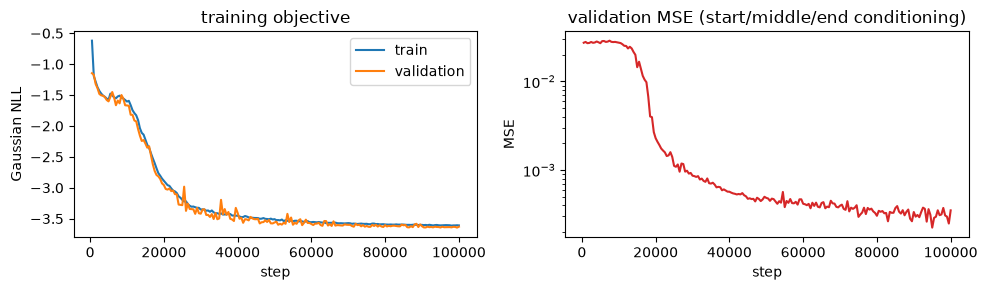

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].plot(history["step"], history["train_nll"], label="train")
axes[0].plot(history["step"], history["val_nll"], label="validation")
axes[0].set(xlabel="step", ylabel="Gaussian NLL", title="training objective"); axes[0].legend()
axes[1].semilogy(history["step"], history["val_mse"], color="tab:red")
axes[1].set(xlabel="step", ylabel="MSE", title="validation MSE (start/middle/end conditioning)")
plt.tight_layout(); plt.show()

## 5. Reproducing a movement from goals

Conditioning on the desired start, intermediate and end positions of a *held-out*
demonstration (Fig. 2e–h of the paper). The shaded band is $\mu \pm 2\sigma$.

The intermediate point matters here: start and end alone do not say which side of the
obstacle to take, so the prediction would (correctly) stay uncommitted — see section 7.

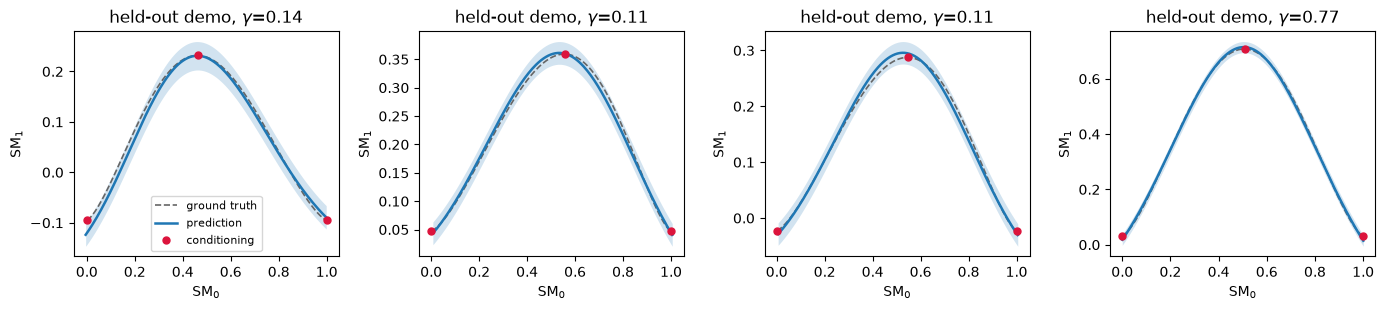

mean absolute error per SM dim: ['0.0034', '0.0123']


In [7]:
def to_np(t):
    return t.detach().cpu().numpy()


def plot_task_space(ax, mean, std, gt=None, ctx=None, title="", band=True):
    mean, std = to_np(mean), to_np(std)
    if gt is not None:
        ax.plot(*to_np(gt).T, color="0.4", ls="--", lw=1.2, label="ground truth")
    if band:
        ax.fill_between(mean[:, 0], mean[:, 1] - 2 * std[:, 1], mean[:, 1] + 2 * std[:, 1],
                        color="tab:blue", alpha=0.20, lw=0)
    ax.plot(mean[:, 0], mean[:, 1], color="tab:blue", lw=1.8, label="prediction")
    if ctx is not None and len(ctx):
        ax.plot(*to_np(ctx).T, "o", color="crimson", ms=5, label="conditioning", ls="none")
    ax.set(title=title, xlabel="SM$_0$", ylabel="SM$_1$")


# start, middle and end: the middle point is what tells the model which side to take
eval_batch = val_sampler.full_target_batch(torch.arange(NUM_VAL), goal_idx)
mean, std = model.predict(**eval_batch.inputs())

fig, axes = plt.subplots(1, 4, figsize=(14, 3.2))
for k, ax in enumerate(axes):
    plot_task_space(ax, mean[k], std[k], gt=eval_batch.tar_y[k], ctx=eval_batch.obs_y[k],
                    title=fr"held-out demo, $\gamma$={eval_batch.gamma[k, 0]:.2f}")
axes[0].legend(fontsize=8)
plt.tight_layout(); plt.show()

err = (mean - eval_batch.tar_y).abs().mean(dim=(0, 1))
print("mean absolute error per SM dim:", [f"{e:.4f}" for e in to_np(err)])

## 6. Varying the number of observations

The same model handles any number of context points — including numbers it never saw
during training. Uncertainty shrinks as observations accumulate.

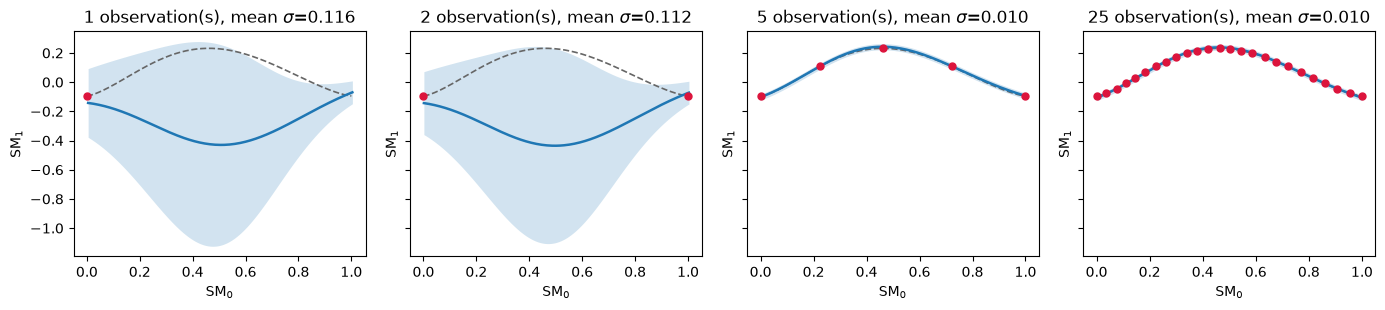

In [8]:
demo = 0
fig, axes = plt.subplots(1, 4, figsize=(14, 3.2), sharey=True)
for ax, n_obs in zip(axes, [1, 2, 5, 25]):
    idx = torch.linspace(0, T_STEPS - 1, n_obs).round().long()
    b = val_sampler.full_target_batch(torch.tensor([demo]), idx)
    mu, sd = model.predict(**b.inputs())
    plot_task_space(ax, mu[0], sd[0], gt=b.tar_y[0], ctx=b.obs_y[0],
                    title=f"{n_obs} observation(s), mean $\\sigma$={sd.mean():.3f}")
plt.tight_layout(); plt.show()

## 7. Multi-modality: the conditioning selects the mode

`γ` does not say which side of the obstacle to take. A single intermediate observation
does — and the model then commits to a low-variance trajectory of that mode
(Sec. IV-A of the paper).

Note the honest failure case in the third panel: conditioned only on the start, the true
predictive distribution is bimodal, but a CNP emits a *unimodal* Gaussian per query point,
so it can only report a wide, non-committal band (or drift toward one mode).

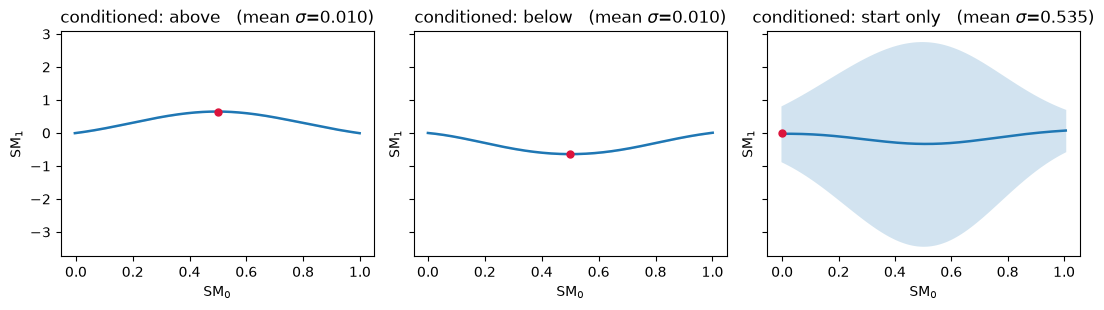

In [9]:
gamma_test = 0.7
peak = 0.25 + 0.55 * gamma_test
queries = [
    ("above", [[0.5]], [[0.5, +peak]]),
    ("below", [[0.5]], [[0.5, -peak]]),
    ("start only", [[0.0]], [[0.0, 0.0]]),
]

fig, axes = plt.subplots(1, 3, figsize=(11, 3.2), sharey=True)
for ax, (name, obs_t, obs_sm) in zip(axes, queries):
    q = build_query(obs_x=obs_t, obs_y=obs_sm, tar_x=time_grid, gamma=[gamma_test], device=device)
    mu, sd = model.predict(**q)
    plot_task_space(ax, mu[0], sd[0], ctx=torch.tensor(obs_sm),
                    title=f"conditioned: {name}   (mean $\\sigma$={sd.mean():.3f})")
plt.tight_layout(); plt.show()

## 8. Generalisation over the task parameter

`γ` was sampled uniformly from $[0, 1]$ during training. Interpolation inside that range is
accurate; extrapolation degrades, exactly as in Table I / Fig. 8 of the paper.

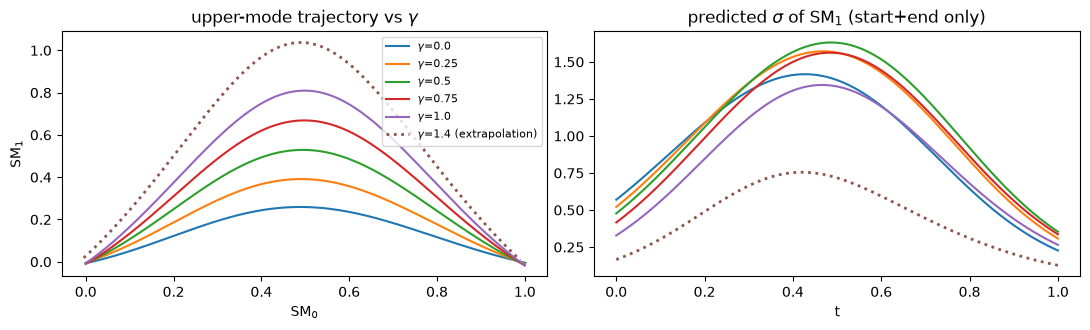

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
for gamma_value in [0.0, 0.25, 0.5, 0.75, 1.0, 1.4]:
    outside = gamma_value > 1.0
    q = build_query(obs_x=[[0.0], [1.0]], obs_y=[[0.0, 0.0], [1.0, 0.0]],
                    tar_x=time_grid, gamma=[gamma_value], device=device)
    mu, sd = model.predict(**q)
    # break the tie towards the upper mode by also observing a point above the obstacle
    q_up = build_query(obs_x=[[0.0], [0.5], [1.0]],
                       obs_y=[[0.0, 0.0], [0.5, 0.25 + 0.55 * gamma_value], [1.0, 0.0]],
                       tar_x=time_grid, gamma=[gamma_value], device=device)
    mu_up, _ = model.predict(**q_up)
    style = dict(ls=":" if outside else "-", lw=2 if outside else 1.5)
    label = fr"$\gamma$={gamma_value}" + (" (extrapolation)" if outside else "")
    axes[0].plot(*to_np(mu_up[0]).T, label=label, **style)
    axes[1].plot(to_np(time_grid)[:, 0], to_np(sd[0])[:, 1], label=label, **style)
axes[0].set(title=r"upper-mode trajectory vs $\gamma$", xlabel="SM$_0$", ylabel="SM$_1$")
axes[1].set(title=r"predicted $\sigma$ of SM$_1$ (start+end only)", xlabel="t")
axes[0].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 9. Optional: conditioning on a subset of the SM dimensions

With `value_masking=True` a context point may specify only *some* components of `SM` —
e.g. a force reading without the corresponding joint positions, which is the situation in
Sec. IV-D of the paper. The encoder receives the masked values **and** the mask, so it can
distinguish "this dimension is 0" from "this dimension is unknown".

This changes the encoder input size, so the flag must be set at training time.

In [11]:
masked_sampler = TrajectorySampler(
    Y[train_ids], x=time_grid, gamma=G[train_ids], n_max=N_MAX, m_max=M_MAX,
    value_masking=True, value_mask_prob=0.5, device=device, seed=2,
)
b = masked_sampler.random_batch(4)
print("obs_value_mask:", tuple(b.obs_value_mask.shape))
print(b.obs_value_mask[0, :5].int().tolist(), "<- first 5 context points of element 0")

masked_model = CNMP(input_dim=1, output_dim=2, param_dim=1, latent_dim=128,
                    encoder_hidden_dims=(128, 128), decoder_hidden_dims=(128, 128),
                    value_masking=True, device=device)
opt = torch.optim.Adam(masked_model.parameters(), lr=1e-3)
MASKED_STEPS = 6000
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=MASKED_STEPS, eta_min=1e-4)

for step in range(1, MASKED_STEPS + 1):
    batch = masked_sampler.random_batch(BATCH)
    mean, std = masked_model(**batch.inputs())
    loss = masked_model.loss(mean, std, *batch.targets())
    opt.zero_grad(set_to_none=True)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(masked_model.parameters(), 5.0)
    opt.step(); sched.step()
    if step % 1500 == 0:
        print(f"step {step:5d} | train {loss.item():7.3f}")

obs_value_mask: (4, 32, 2)
[[1, 0], [1, 0], [1, 1], [1, 0], [1, 0]] <- first 5 context points of element 0
step  1500 | train  -1.575
step  3000 | train  -2.046
step  4500 | train  -2.413
step  6000 | train  -2.755


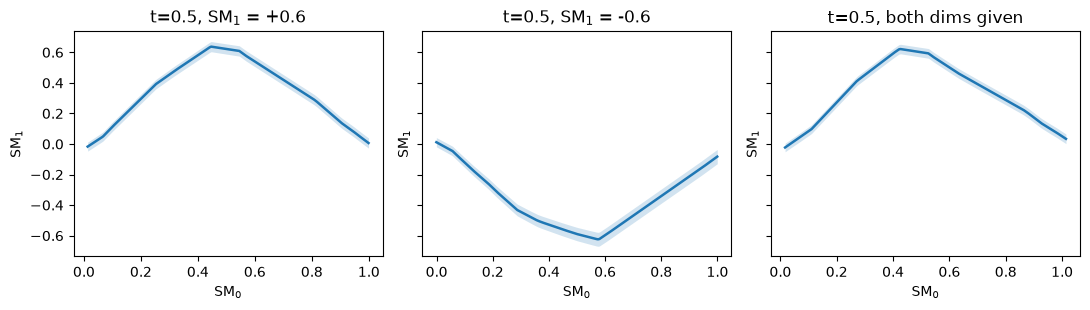

In [12]:
# observe *only* SM_1 (the "which side" evidence) at t=0.5, leaving SM_0 unknown
fig, axes = plt.subplots(1, 3, figsize=(11, 3.2), sharey=True)
for ax, (name, value) in zip(axes, [("SM$_1$ = +0.6", 0.6), ("SM$_1$ = -0.6", -0.6),
                                    ("both dims given", None)]):
    if value is None:
        q = build_query(obs_x=[[0.5]], obs_y=[[0.5, 0.6]], tar_x=time_grid,
                        gamma=[0.7], obs_value_mask=[[1, 1]], device=device)
    else:
        q = build_query(obs_x=[[0.5]], obs_y=[[0.0, value]], tar_x=time_grid,
                        gamma=[0.7], obs_value_mask=[[0, 1]], device=device)
    mu, sd = masked_model.predict(**q)
    plot_task_space(ax, mu[0], sd[0], title=f"t=0.5, {name}")
plt.tight_layout(); plt.show()

## 10. Saving and loading

`model.save` stores the constructor arguments next to the weights, so a checkpoint is
self-describing.

In [13]:
model.save(f"{ckpt_path}/cnmp_final.pt")
reloaded = CNMP.load(f"{ckpt_path}/cnmp_final.pt", device=device)
q = build_query(obs_x=[[0.0], [1.0]], obs_y=[[0.0, 0.0], [1.0, 0.0]],
                tar_x=time_grid, gamma=[0.5], device=device)
a, _ = model.predict(**q)
b, _ = reloaded.predict(**q)
print("identical predictions after reload:", torch.allclose(a, b))
print("config:", reloaded.config)

identical predictions after reload: True
config: {'input_dim': 1, 'output_dim': 2, 'param_dim': 1, 'latent_dim': 128, 'encoder_hidden_dims': (128, 128), 'decoder_hidden_dims': (128, 128), 'min_std': 0.01, 'value_masking': False, 'activation': 'gelu', 'layer_norm': False}
